# SVM Exercises

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn import metrics

Load Pima diabetes dataset

In [3]:
url = "https://raw.githubusercontent.com/BeaverWorksMedlytics2020/Data_Public/master/NotebookExampleData/Week1/diabetes.csv"
names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

# YOUR CODE HERE
data = pd.read_csv(url, names = names)

invalid = ['plas', 'pres', 'skin', 'test', 'mass']

for i in invalid:
    data[i].replace(to_replace=0, value=np.nan, inplace=True)

data = data.dropna(axis=0).reset_index(drop=True)

data.head()

/tmp/ipykernel_1684/835836153.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[i].replace(to_replace=0, value=np.nan, inplace=True)


,preg,plas,pres,skin,test,mass,pedi,age,class
0,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
1,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
2,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
3,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
4,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1


Split data into training, colidation, and test sets with a test size of 25%

In [6]:
# YOUR CODE HERE
X_cols =  ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age']

y_col = ['class']

test_size = 0.25

X_train, X_test, y_train, y_test = train_test_split(data[X_cols], data[y_col], test_size=test_size, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, random_state=0)

Create a model with sklearn's SVC and a high gamma value (perhaps 1.0)

In [9]:
model = SVC(gamma=1.0)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(gamma=1.0)

Print accuracy of training and validation data

In [15]:
# YOUR CODE HERE
Training_predictions = model.predict(X_train)
Training_accuracy = accuracy_score(y_train, Training_predictions)

Validation_predictions = model.predict(X_val)
Validation_accuracy = accuracy_score(y_val, Validation_predictions)

print("Training accuracy is", Training_accuracy)
print("Validation accuracy is", Validation_accuracy)

Training accuracy is 1.0
Validation accuracy is 0.6756756756756757


Create a model with sklearn's SVC and a low gamma value (perhaps .001)

In [16]:
# YOUR CODE HERE
model = SVC(gamma=0.001)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(gamma=0.001)

Print accuracy of training and validation data

In [17]:
# YOUR CODE HERE
Training_predictions = model.predict(X_train)
Training_accuracy = accuracy_score(y_train, Training_predictions)

Validation_predictions = model.predict(X_val)
Validation_accuracy = accuracy_score(y_val, Validation_predictions)

print("Training accuracy is", Training_accuracy)
print("Validation accuracy is", Validation_accuracy)

Training accuracy is 0.8727272727272727
Validation accuracy is 0.7432432432432432


Explain the accuracy results below.

(YOUR ANSWER HERE)
The first model is overfit, it accuratly predicted all the training data but had a substantial decrease when faced with unseen data. Model two is a more general model, the training accuracy doesn't reach 100% but validation accuracy is significanly better than model one's.

Print the confusion matrices for your high and low gamma models (both numeric and visualized)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


High Gamma (1.0) Confusion Matrix:
[[50  0]
 [24  0]]


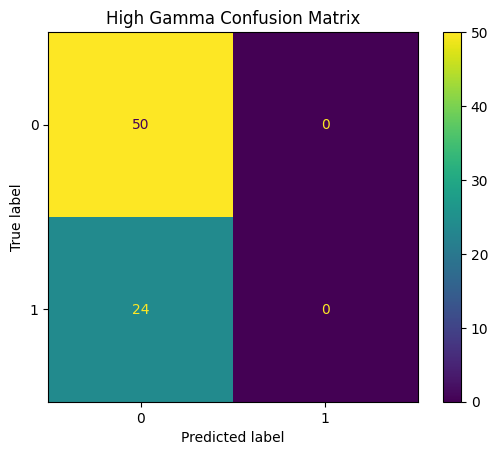

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Low Gamma (0.01) Confusion Matrix:
[[50  0]
 [24  0]]


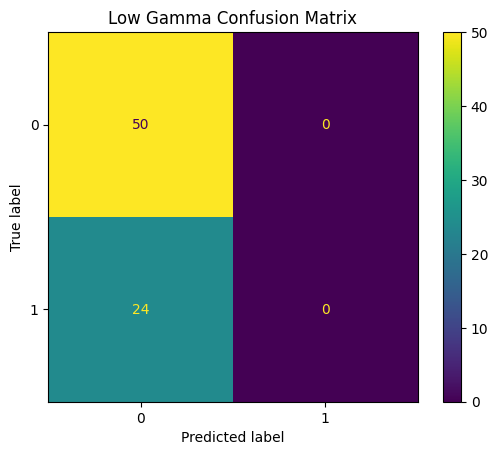

In [26]:
# YOUR CODE HERE

from sklearn.metrics import confusion_matrix

high_gamma_model = SVC(gamma=1.0)
high_gamma_model.fit(X_train, y_train)

y_pred = high_gamma_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

print("High Gamma (1.0) Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("High Gamma Confusion Matrix")
plt.show()

low_gamma_model = SVC(gamma=0.01)
low_gamma_model.fit(X_train, y_train)

y_pred = low_gamma_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

print("Low Gamma (0.01) Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(cm).plot()
plt.title("Low Gamma Confusion Matrix")
plt.show()